In [4]:
import numpy as np
from numpy.linalg import eigh
from scipy.linalg import eigh, expm, svd
import sys
import os
import warnings
warnings.filterwarnings('ignore', category=UserWarning, append = True)


import tenpy
from tenpy.networks.mps import MPS
from tenpy.algorithms import dmrg, tebd
from tenpy.networks.mpo import MPO
from tenpy_toycodes.a_mps import SimpleMPS, init_FM_MPS, init_Neel_MPS
from tenpy_toycodes.b_model import TFIModel
from tenpy_toycodes.d_dmrg import SimpleDMRGEngine, SimpleHeff2, DMRG_tf_ising_finite
from tenpy_toycodes.tfi_exact import finite_gs_energy

import tenpy.linalg.np_conserved as npc
from tenpy.models.tf_ising import TFIChain

import time
import csv
import matplotlib.pyplot as plt
import matplotlib.ticker as tck


Caching the list of root modules, please wait!
(This will only be done once - type '%rehashx' to reset cache!)



The bellow is a class constructed for the TFIM which is featured on the TeNPy website

In [ ]:
def QFI(psi, op):
    """
    Calculate the Quantum Fisher Information (QFI) for a given state and operator.
    
    Parameters:
    psi : MPS
        The matrix product state representing the quantum state.
    op : str
        The operator for which to calculate the QFI ('Sigmax' or 'Sigmaz').
        
    Returns:
    float
        The calculated QFI value.
    """
    # Calculate the expectation value of the operator
    expe = np.mean(psi.expectation_value(op))
    
    # Calculate the correlation function
    corr_q2 = psi.correlation_function(op, op, sites1=None, sites2=None)
    
    # Calculate the expectation value of the squared operator
    expectation_q2 = np.mean(corr_q2)
    
    # Calculate QFI using the formula: QFI = 4 * (expectation_q2 - expe^2)
    qfi = 4 * (expectation_q2 - expe**2)
    
    return qfi

def build_Q_MPO( op = 'Sigmax', model = None, apply_to_GS = False, model_params = {}, dmrg_params = {}):
    """
    builds an MPO corresponding to Q = 1/L sum_i op_i
    if apply_to_GS then it ftn will return op | GS > as a MPS
    """
    if model is None:
        model_type = model_params.get("model_type", "Ising")
        if model_type == "Ising":
            model = TFIChain(model_params)
        else: 
            raise ValueError("Model type not configured yet")
    L = model.lat.N_cells
    Id = model.lat.unit_cell[0].get_op("Id")
    Q = model.lat.unit_cell[0].get_op(op)
        
    W = []
    for i in range(L):
        Wi = np.empty((2, 2), dtype=object)

        Wi[0, 0] = Id
        Wi[1, 1] = Id

        Wi[0, 1] = Q / L
        Wi[1, 0] = None

        W.append(Wi)

    mpo = MPO.from_grids(model.lat.mps_sites(), W, IdL=0, IdR=1)

    if apply_to_GS:

        #DMRG engine
        psi = MPS.from_lat_product_state(model.lat, [['up']])
        eng = dmrg.TwoSiteDMRGEngine(psi, model, dmrg_params)
        E0, psi = eng.run()

        phi = psi.copy()
        mpo.apply(phi, options={'compression_method' : 'SVD'})
        return model, E0, psi, phi 

    return mpo

def TEBD_initialize(phi, model, tebd_params, E0 = None):
    """Initialize the TEBD engine with appropriate start time"""
    
    phi_t = phi.copy()
    start_time = tebd_params.get('start_time',0)
    engine = tebd.TEBDEngine(phi_t, model, tebd_params)
    engine.evolved_time = 0

    if start_time > 0 and start_time < 0.05:
        engine.calc_U(2, start_time)
        engine.evolve( 1,   dt = start_time)
        engine.evolved_time = round(engine.evolved_time, 4)
    elif start_time >0:
        initial_steps = int(start_time * 20)
        engine.calc_U(2, start_time/initial_steps )
        engine.evolve(initial_steps,   dt = start_time/initial_steps)
        engine.evolved_time = round(engine.evolved_time, 4)
    engine.calc_U(2, tebd_params['dt'] )

    if E0 is not None:
        times = [engine.evolved_time]
        corr = [np.real(phi.overlap(phi_t)* np.exp(1j * E0 * start_time))]  # 1/2 <psi | {Q(t), Q} | psi > = Re[< phi | U | phi > exp(i E_0 t)]
    
        return phi_t, times, corr, engine
    
    return phi_t, engine

def calculate_QtQ(op, model_params,   dmrg_tebd_params , calc_upto_2t = False ):
    """ Calculates 1/2 < psi | {Q(t), Q} | psi > 
        for psi the ground state of model """
    extra_params = dmrg_tebd_params

    #DMRG engine
    # apply phi = Q |psi > Must be careful here because some processes
    # in MPS and MPO by default normalize the output wavefunction
    M, E0, psi, phi = build_Q_MPO( op, apply_to_GS= True, model_params=model_params, dmrg_params = dmrg_tebd_params)

    # TEBD engine
    phi_t, times, expec_U, engine = TEBD_initialize(phi, M, dmrg_tebd_params, E0 = E0)

    for _ in range(extra_params.get('N_times', 1)):

        engine.run()
        t = engine.evolved_time
        times.append(round(t, 4))
        expec_U.append(np.real(phi.overlap(phi_t) * np.exp(1j * E0 * t)))
        
    if calc_upto_2t: #option used for calculate_LG_correlator which combines two legs 
                     #of time and expec_U for calculating 2 C(t) - C(2t) easily

        extra_params['N_steps'] = 2 * (extra_params['N_steps'])
        extra_params['N_times'] = int( extra_params['N_times']/2)
        engine = tebd.TEBDEngine(phi_t, M, extra_params)
        engine.evolved_time = t
        
        for _ in range(extra_params.get('N_times')):
            
            engine.run()
            t= engine.evolved_time
            expec = np.real(phi.overlap(phi_t) * np.exp(1j * E0 * t))
            times += [-100, round(t, 4)]
            expec_U += [-100, expec] #so that if the implementation is wrong we will see it in the data
        
    return times, expec_U


def calculate_LG_correlator(op, model_params,   dmrg_tebd_params ):
    """Returns  2 [C(t) - C(0)] - [C(2t) - C(0)], 2C(t) - C(2t) """

    #Calculates C values from 0 to time_end
    times, corr = calculate_QtQ(op, model_params,   dmrg_tebd_params , calc_upto_2t  = True )    #Calculates only the extra C values needed to calculate K

    half_len = len(times)//2 +1
    LG_B_lst = []
    K_lst = []
    # LG_B = 2C(t) - C(2t) - C(0)
    for i in range(half_len):
        LG_B_lst += [corr[i] * 2 - corr[2 * i] - corr[0] + .1]
        K_lst += [corr[i] * 2 - corr[2 * i] +.1]
        
    return times[: half_len] , LG_B_lst, K_lst 

def calculate_LG_bound(op, model_params,   dmrg_tebd_params ):
    """Calculates the lower bound on the QFI set by the LG correlator QFI > 8 LG_B_Max"""

    dt = dmrg_tebd_params['dt']
    t_max = dmrg_tebd_params['t_max']
    N_steps = dmrg_tebd_params['N_steps']
    dmrg_tebd_params['N_times'] = 2 * int(t_max /(2 * dt * N_steps))

    times, LG_B, Kt = calculate_LG_correlator(op, model_params,   dmrg_tebd_params )

    return 8 * np.max(LG_B)


def calculate_LG_bound1(op, model_params,   dmrg_tebd_params ):
    """Calculates the lower bound on the QFI set by the LG correlator QFI > 8 LG_B_Max
       using a "search a little after the first local maximum" algorithm """
  
    #Initialize model and phi through building the Q_MPO
    M, E0, psi, phi = build_Q_MPO( op, apply_to_GS= True, model_params=model_params, dmrg_params = dmrg_tebd_params)

    # TEBD engine
    phi_t, times, corr, engine = TEBD_initialize(phi, M, dmrg_tebd_params, E0 = E0)
    
    LG_B_vals = []
    best_LG_B = -np.inf
    best_t = 0
    i = 0
    i_max = np.inf
    max_iter = 3

    while True:     #loop until the end
        #construct the time correlator list
        engine.run()
        t = engine.evolved_time
        corr.append(np.real(phi.overlap(phi_t) * np.exp(1j * E0 * t)))

        while 2 *i <= len(corr):    #when the correlator list is long enough calculate...
            LG_B = 2*corr[i] - corr[2*i] - corr[0]
            LG_B_vals.append(LG_B)

            if LG_B > best_LG_B:    #keep track of the largest LG_B value
                best_LG_B = LG_B

                # detect first local maximum
            if len(LG_B_vals) >= 3:
                if LG_B_vals[-2] > LG_B_vals[-3] and LG_B_vals[-2] >= LG_B_vals[-1]:
                    local_max = LG_B_vals[-2]   #LG_B
                    i_max = i                   #index
                    best_t = times[i]           #time
                    max_iter -= 1               #only let 3 local maximums be found
                    
            if i_max +10 < i:   #check after 10 steps after the maximum
                if best_LG_B > local_max and max_iter != 0:   #if there is a better LG_B then reset
                    i_max = np.inf
                else:                       #if nothing beats it then return the last local maximum
                    return best_t, 8 * local_max
            
        i += 1       #incriment the i index by 1

In [ ]:
n = 4

model_params = {
    'J': .1 , 'g': 1,  # critical
    'L': 4,
    'bc_MPS': 'finite',
    'model_type' : "Ising",
    'conserve' : None
}

extra_params = {
    'mixer': None,  # setting this to True helps to escape local minima
    'max_E_err': 1.e-10,
    'trunc_params': {
        'chi_max': 100,
        'svd_min': 1.e-10,
    },
    'verbose': False,
    'combine': True,
    'N_times' : n,  #Only even N_times are used for K,
    'dt': 0.02,'N_steps': 2,
    'order': 2,
    'start_time' : 0  ,
    't_max' : 30  #only an option for calculating the bound
}
start1 = time.perf_counter()
print(calculate_LG_bound1('Sigmax', model_params, extra_params))
end1 = time.perf_counter()

print(end1 - start1)


KeyboardInterrupt



: 

final DMRG state not in canonical form up to norm_tol=1.00e-05: norm_err=3.35e-02


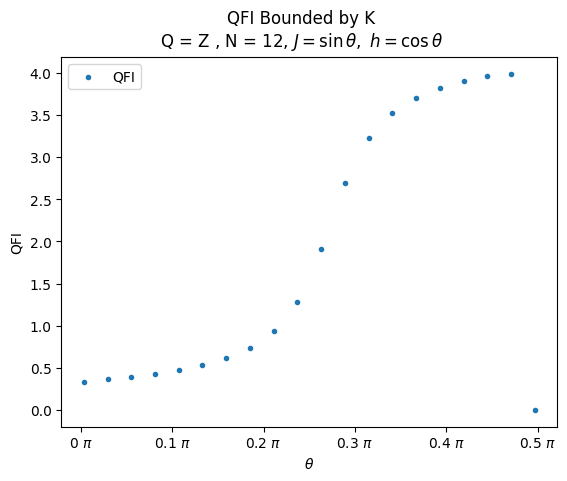

In [35]:
L = 12
chi_max = 20
op = 'Sigmax'
num_points = 20

dmrg_params = {
        'mixer': True,  # setting this to True helps to escape local minima
        'max_E_err': 1.e-10,
        'trunc_params': {
            'chi_max': chi_max,
            'svd_min': 1.e-10,
        },
        'combine': True
    }

theta_range = np.linspace(.01, np.pi/2- .01, num_points)

fig, ax = plt.subplots(1)

LG_bound = []
QFI_lst =[]
for theta in theta_range:
    J, g = np.sin(theta), np.cos(theta)

    model_params = {
    'J':  J , 'g':  g,  # critical
    'L': L,
    'bc_MPS': 'finite',
    'conserve' : None}

    M = TFIChain(model_params)
    psi = MPS.from_lat_product_state(M.lat, [['up', 'down']], allow_incommensurate= True)
    
    eng = dmrg.TwoSiteDMRGEngine(psi, M, dmrg_params)
    E, psi = eng.run() # the main work; modifies psi in place
    
    
    #Generate QFI
    QFI_lst += [QFI(psi, op)] #[qfi3]

#ax.fill_between(theta_range/ np.pi, LG_bound, 4 ,  color = '.7', label = "QFI Bound "  )
ax.scatter(theta_range/ np.pi, QFI_lst, marker = '.', label = "QFI", zorder = 3)


fig.suptitle("QFI Bounded by K\nQ = Z , N = " + str(L) + ", $J = \\sin\\theta,~h = \\cos\\theta$")
ax.xaxis.set_major_formatter(tck.FormatStrFormatter("%g $\\pi$"))
plt.xlabel("$\\theta$")
ax.set(ylabel = "QFI")
#plt.ylim((0.9,1.6))
plt.legend()

plt.show()

In [33]:
fig.savefig("C:\\Users\\ianro\\Documents\\Research\\Quantum_Metrology_AKLT\\Plots\\TFIM_L50_Ztot_QFI_Bound.png")

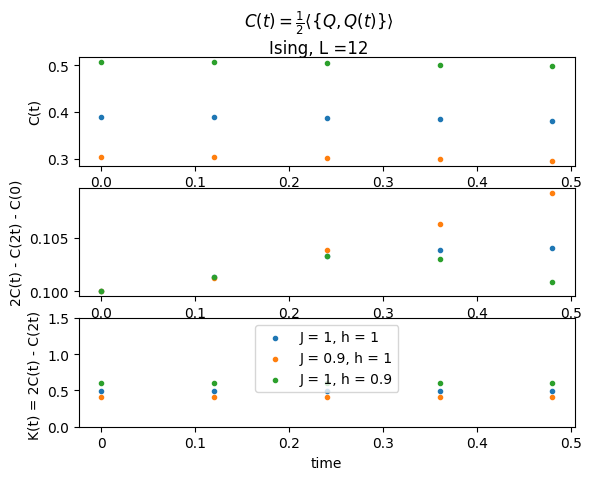

In [87]:
L = 12
chi_max = 30
op = 'Sigmax'
num_points = 4
t_end = .5 
dt = 0.02
Jg_lst = [[1,1],[.9,1], [1, .9]]

fig, ax = plt.subplots(3)

for J, g in Jg_lst: 

    model_params = {
        'J': J , 'g': g, 
        'L': L,
        'bc_MPS': 'finite',
        'model_type' : "Ising",
        'conserve' : None    }
    
    extra_params = {
    'mixer': None,  # setting this to True helps to escape local minima
    'max_E_err': 1.e-10,
    'trunc_params': {
        'chi_max': chi_max,
        'svd_min': 1.e-10,
    },
    'verbose': False,
    'combine': True,
    'N_times' : num_points,
    'dt': dt,'N_steps': 2*int( t_end//(2*dt * num_points)),
    'order': 2, 'start_time' : 0}

    times, Ct = calculate_QtQ('Sigmax', model_params,  dmrg_tebd_params = extra_params)
    ax[0].scatter(times, Ct, marker = '.', label = "J = " + str(J) + ", h = " + str(g), zorder = 3)
    times, LG_correl, Kt = calculate_LG_correlator('Sigmax', model_params,  dmrg_tebd_params = extra_params)
    ax[1].scatter(times, LG_correl, marker = '.', label = "J = " + str(J) + ", h = " + str(g), zorder = 3)
    ax[2].scatter(times, Kt, marker = '.', label = "J = " + str(J) + ", h = " + str(g), zorder = 3)


fig.suptitle("$C(t) = \\frac{1}{2}\\langle \\{Q, Q(t) \\}\\rangle$\nIsing, L =" + str(L))
ax[2].xaxis.set_major_formatter(tck.FormatStrFormatter("%g"))
plt.xlabel("time")
ax[0].set(ylabel = "C(t)")
ax[1].set(ylabel = "2C(t) - C(2t) - C(0)")
ax[2].set(ylabel = "K(t) = 2C(t) - C(2t) ")
ax[2].set_ylim([0,1.5])
plt.legend()

plt.show()

In [22]:
fig.savefig("C:\\Users\\ianro\\Documents\\Research\\Quantum_Metrology_AKLT\\Plots\\TFIM_L50_C_LG_K.png")

KeyboardInterrupt: 

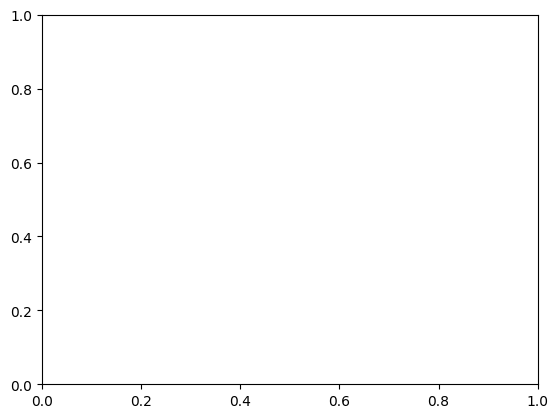

In [39]:
L = 4
chi_max = 30
op = 'Sigmax'
num_points = 15

extra_params = {
    'mixer': None,  # setting this to True helps to escape local minima
    'max_E_err': 1.e-10,
    'trunc_params': {
        'chi_max': 30,
        'svd_min': 1.e-10,
    },
    'verbose': False,
    'combine': True,
    'N_times' : 4,  #Only even N_times are used for K,
    'dt': 0.02,'N_steps': 2,
    'order': 2,
    'start_time' : 0  ,
    't_max' : 25  #only an option for calculating the bound
}

theta_range = np.linspace(0.18 * np.pi, 0.31 * np.pi, num_points)

fig, ax = plt.subplots(1)

LG_bound = []
QFI_lst =[]
for theta in theta_range:
    J, g = np.sin(theta), np.cos(theta)

    model_params = {
    'J':  J , 'g':  g,  # critical
    'L': L,
    'bc_MPS': 'finite',
    'conserve' : None}

    LG_bound += [calculate_LG_bound(op, model_params, extra_params )]

#ax.fill_between(theta_range/ np.pi, LG_bound, 4 ,  color = '.7', label = "QFI Bound "  )
ax.scatter(theta_range/ np.pi, LG_bound, marker = '.', label = "", zorder = 3)


fig.suptitle("QFI Bounded by K\nQ = Z , N = " + str(L) + ", $J = \\sin\\theta,~h = \\cos\\theta$")
ax.xaxis.set_major_formatter(tck.FormatStrFormatter("%g $\\pi$"))
plt.xlabel("$\\theta$")
ax.set(ylabel = "QFI")
#plt.ylim((0.9,1.6))
plt.legend()

plt.show()